# Business Understanding


### Project Domain

Project Domain di sini adalah membuat aplikasi prediksi risiko stroke menggunakan data medis. Aplikasi ini bertujuan untuk membantu profesional medis atau masyarakat umum dalam menilai kemungkinan seseorang terkena stroke berdasarkan faktor-faktor risiko medis seperti umur, hipertensi, penyakit jantung, dan lainnya.

## Problem Statements

Masalah yang dihadapi adalah kurangnya alat yang mudah diakses untuk memprediksi risiko stroke berdasarkan data medis yang terbatas. Hal ini dapat menyebabkan keterlambatan diagnosis atau pengobatan. Oleh karena itu, dengan menggunakan data medis yang tersedia, kita dapat membangun model untuk memprediksi kemungkinan stroke pada pasien.

## Goals

1. Mengembangkan aplikasi berbasis web yang dapat memprediksi kemungkinan seseorang terkena stroke.

2. Meningkatkan pemahaman dan kesadaran masyarakat mengenai faktor-faktor risiko stroke.

3. Menyediakan alat yang mudah digunakan bagi tenaga medis untuk memberikan diagnosa awal.

## Solution Statements

Kami akan mengembangkan model machine learning menggunakan dataset Stroke Prediction untuk memprediksi kemungkinan stroke berdasarkan faktor-faktor risiko. Model ini akan diterapkan dalam aplikasi web menggunakan Streamlit, memungkinkan pengguna untuk memasukkan data dan mendapatkan hasil prediksi.



# Data Understanding

In [3]:
from google.colab import files
uploaded = files.upload()


Saving kaggle.json to kaggle.json


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset


Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors


In [6]:
!mkdir stroke-prediction-dataset
!unzip stroke-prediction-dataset.zip -d stroke-prediction-dataset
!ls stroke-prediction-dataset

Archive:  stroke-prediction-dataset.zip
  inflating: stroke-prediction-dataset/healthcare-dataset-stroke-data.csv  
healthcare-dataset-stroke-data.csv


## Import Library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import load_model


## Exploratory Data Analysis

In [7]:
df = pd.read_csv("stroke-prediction-dataset/healthcare-dataset-stroke-data.csv")


In [8]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


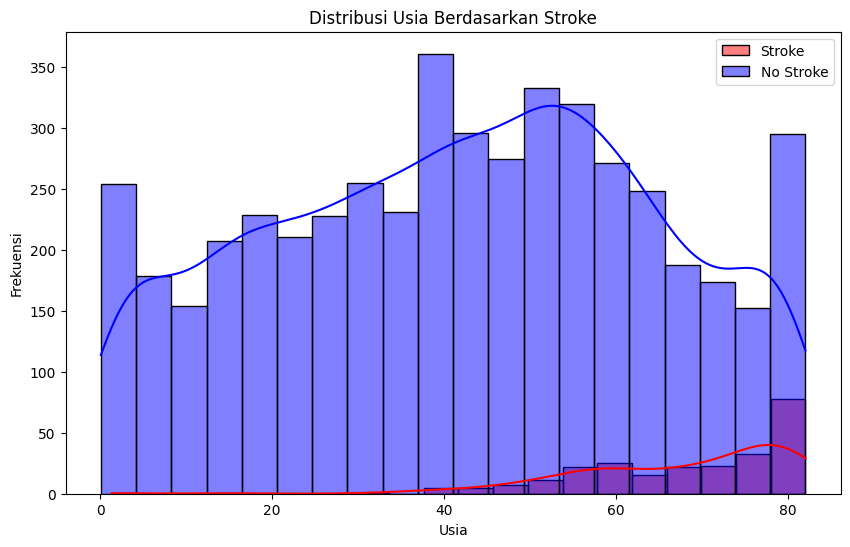

In [10]:
# Plot distribusi usia berdasarkan stroke
plt.figure(figsize=(10, 6))
sns.histplot(df[df['stroke'] == 1]['age'], kde=True, color='red', label='Stroke', bins=20)
sns.histplot(df[df['stroke'] == 0]['age'], kde=True, color='blue', label='No Stroke', bins=20)
plt.title('Distribusi Usia Berdasarkan Stroke')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

<ipython-input-11-e13ccc560bd6>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y='avg_glucose_level', palette='Set2')


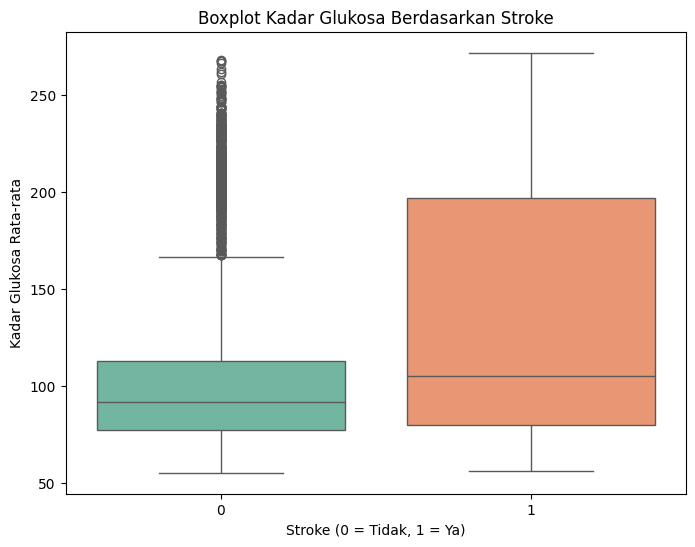

In [11]:
# Boxplot kadar glukosa berdasarkan stroke
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level', palette='Set2')
plt.title('Boxplot Kadar Glukosa Berdasarkan Stroke')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('Kadar Glukosa Rata-rata')
plt.show()

<ipython-input-12-4ec7b4c6d4a2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='stroke', y='bmi', palette='Set2')


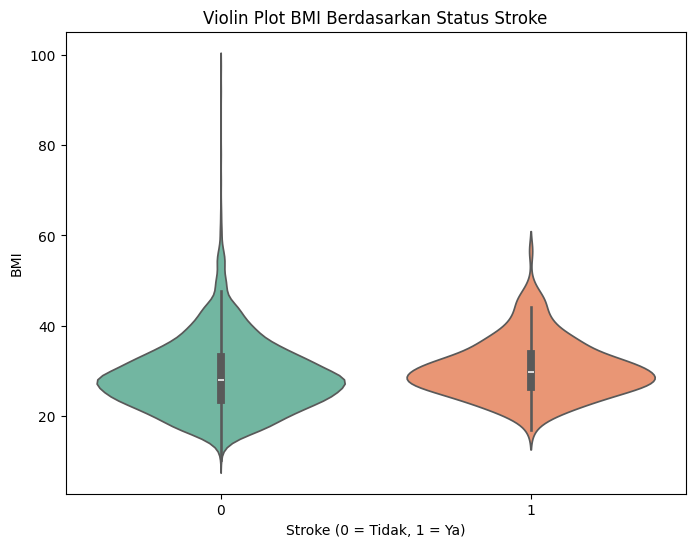

In [12]:
# Violin plot BMI berdasarkan status stroke
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='stroke', y='bmi', palette='Set2')
plt.title('Violin Plot BMI Berdasarkan Status Stroke')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('BMI')
plt.show()

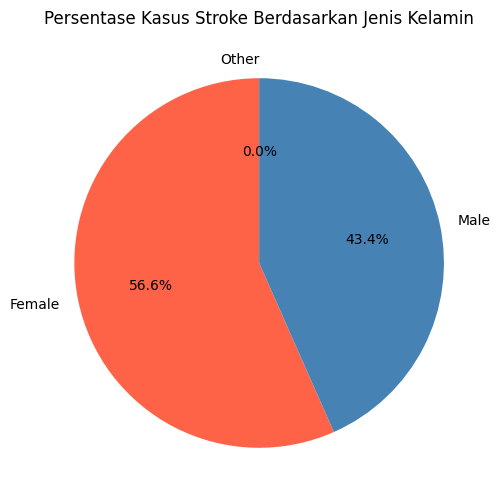

In [13]:
# Pie Chart distribusi stroke berdasarkan gender
gender_stroke_counts = df.groupby(['gender', 'stroke']).size().unstack().fillna(0)
plt.figure(figsize=(6, 6))
plt.pie(gender_stroke_counts[1], labels=gender_stroke_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6347', '#4682B4'])
plt.title('Persentase Kasus Stroke Berdasarkan Jenis Kelamin')
plt.show()

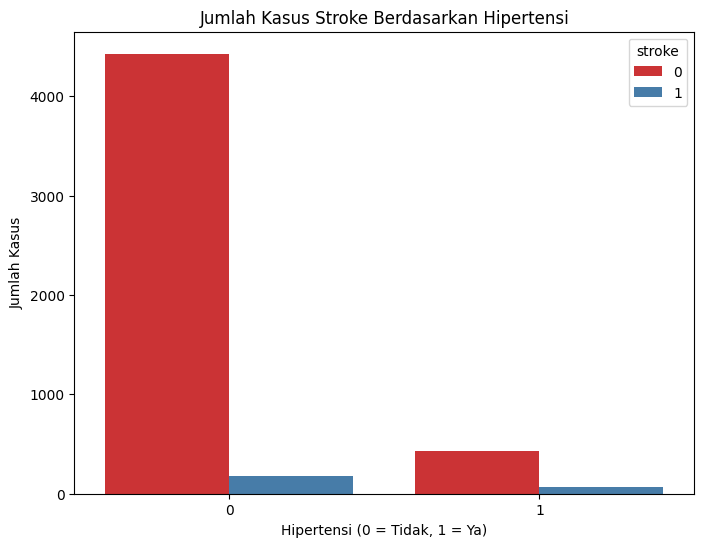

In [14]:
# Plot distribusi stroke berdasarkan hipertensi
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='hypertension', hue='stroke', palette='Set1')
plt.title('Jumlah Kasus Stroke Berdasarkan Hipertensi')
plt.xlabel('Hipertensi (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Kasus')
plt.show()


In [15]:
le = LabelEncoder()


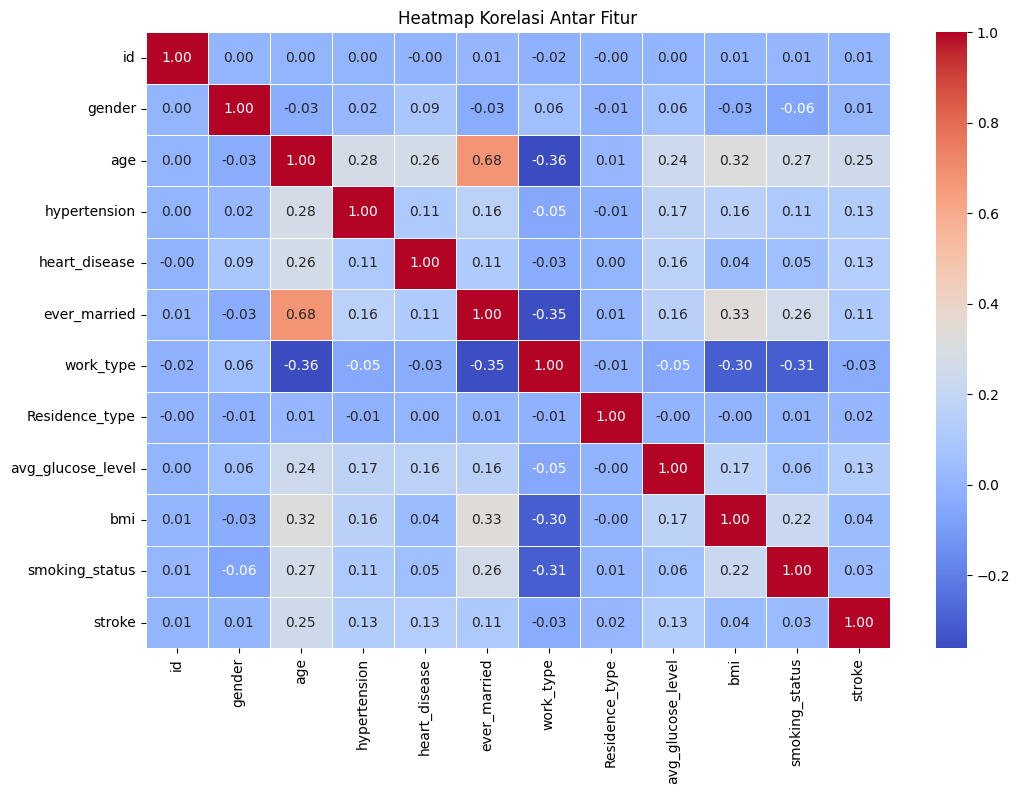

In [16]:
# Menampilkan heatmap korelasi
categorical_columns = ['gender', 'work_type', 'smoking_status', 'ever_married', 'Residence_type']
for col in categorical_columns: df[col] = le.fit_transform(df[col])
df.fillna(df.median(), inplace=True)
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


# Data Preparation


In [18]:
# Data Preparation
if 'id' in df.columns:
    df = df.drop(columns=['id'])
df_encoded = pd.get_dummies(df, drop_first=True)

In [19]:
# Pisahkan fitur dan target
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']


In [20]:
# Simpan nama kolom untuk referensi input baru nanti
feature_columns = X.columns.tolist()


In [21]:
# Encode label target (0 = tidak stroke, 1 = stroke)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
# Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

In [24]:
# Split data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Modeling

In [25]:
# Membangun model ANN
model = Sequential()
model.add(Dense(16, activation ='relu', input_shape=(X_train.shape[1],))) # Hidden layer
model.add(Dense (8, activation ='relu')) # Hidden layer kedua
model.add(Dense (1, activation ='sigmoid')) # Output layer untuk klasifikasi biner

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

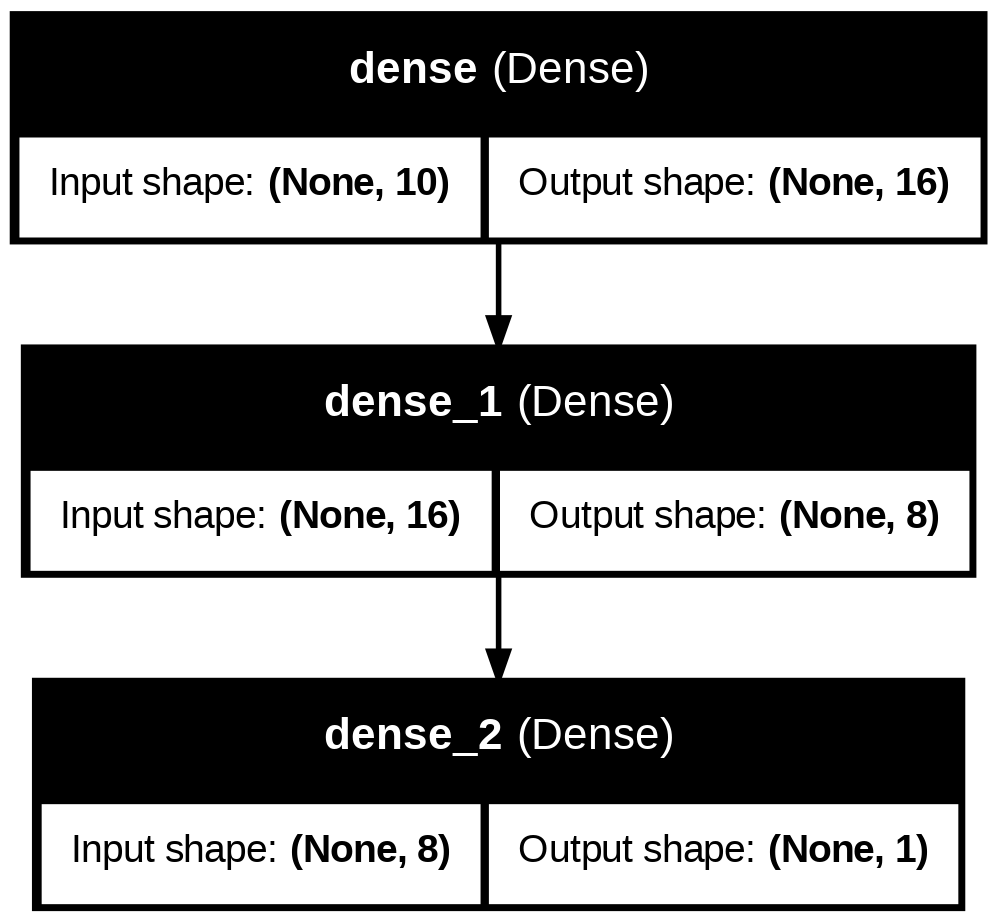

In [28]:
# Plot arsitektur model
plot_model (model, show_shapes=True, show_layer_names=True)

In [29]:
# Melatih model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))


Epoch 1/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5940 - loss: 0.6672 - val_accuracy: 0.7553 - val_loss: 0.5330
Epoch 2/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7578 - loss: 0.5204 - val_accuracy: 0.7846 - val_loss: 0.4752
Epoch 3/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7791 - loss: 0.4771 - val_accuracy: 0.7851 - val_loss: 0.4595
Epoch 4/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7808 - loss: 0.4701 - val_accuracy: 0.7799 - val_loss: 0.4639
Epoch 5/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7765 - loss: 0.4647 - val_accuracy: 0.7835 - val_loss: 0.4607
Epoch 6/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7881 - loss: 0.4573 - val_accuracy: 0.7954 - val_loss: 0.4516
Epoch 7/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7866 - loss: 0.4523 - val_accuracy: 0.7861 - val_loss: 0.4535
Epoch 8/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7841 - loss: 0.4614 - val_accuracy: 0.

# Evaluation

In [30]:
# Prediksi pada data test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8101 - loss: 0.4163
Akurasi Model: 0.8010
Loss Model: 0.4223


In [31]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Accuracy')

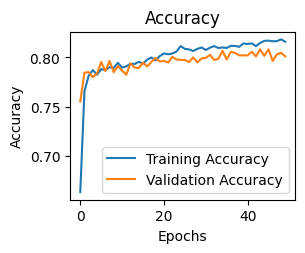

In [32]:
# Plot grafik akurasi pelatihan dan validasi
plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

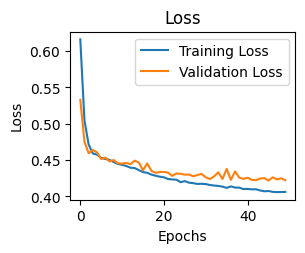

In [33]:
# Plot grafik loss pelatihan dan validasi
plt.subplot(2, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [34]:
# Prediksi pada data uji
y_pred = model.predict(X_test)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [35]:
# Mengubah probabilitas prediksi menjadi kelas biner (0 atau 1)
y_pred_classes = (y_pred > 0.5).astype(int)


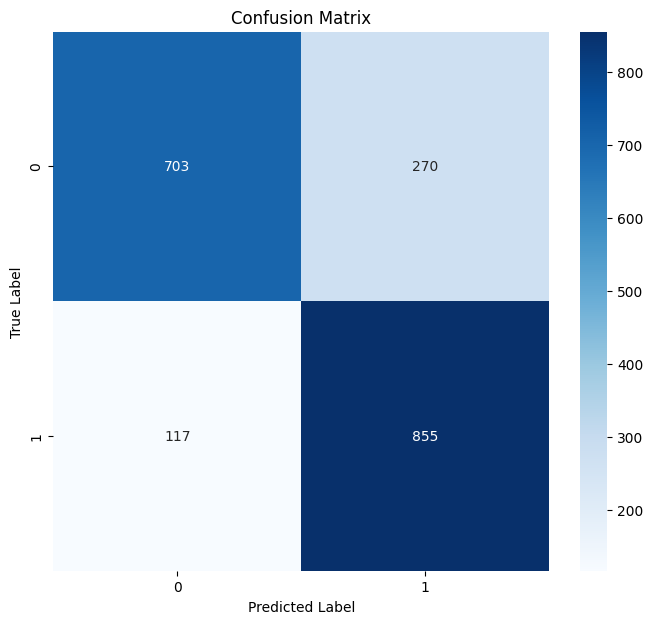

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       973
           1       0.76      0.88      0.82       972

    accuracy                           0.80      1945
   macro avg       0.81      0.80      0.80      1945
weighted avg       0.81      0.80      0.80      1945



In [36]:
# Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 7))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [38]:
# Contoh input data baru (misalnya 11 fitur )
new_data = np.array([[1, 75, 1, 1, 1, 1, 1, 250.0, 38.0, 1]])  # Contoh data

# Normalisasi input data baru
new_data_scaled = scaler.transform(new_data)

# Prediksi
prediction_prob = model.predict(new_data_scaled)
prediction = (prediction_prob > 0.5).astype(int)

# Hasil prediksi
if prediction[0][0] == 1:
    print("Pasien diprediksi TERKENA stroke.")
else:
    print("Pasien diprediksi TIDAK terkena stroke.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Pasien diprediksi TERKENA stroke.


## Save Model

In [39]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('stroke_model.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp5d4_bisg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140625208605392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140625208606160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140625208605968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140625208600016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140625208606544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140625208603280: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [40]:
import joblib
# Setelah fit_transform scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [41]:
from google.colab import files
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
from google.colab import files

tflite_model_path = 'stroke_model.tflite'
files.download(tflite_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>